In [32]:
nth_prime(400)

2741

In [ ]:
from sage.all import *
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
start=time.time()
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)

def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j

D = delta_qexp(4000) 
h_list=[1]+[D[nth_prime(k)] for k in range(1,501)]
j_list=j_sequence_from_h(h_list)
c=1
deformed_j_list=[c]+j_list
deformed_h_list=h_sequence_from_j(deformed_j_list)
print("deformed_h_list[0]:",deformed_h_list[0])

def deformed_h(n):
    return deformed_h_list[n]
    
roots_list=[]    
chi_list=[]
mins_list=[]
log_mins_list=[]
for n in range(1,501):
    print("n:",n,"elapsed:",(time.time()-start)/60)
    chi=0
    for r in range(0,n+1):
        chi+=binomial(n,r)*factorial(r)*deformed_h(r)*(-1)**r*x**(n-r)
    chi_list.append((n,chi))
    roots = chi.roots(ring=CC, multiplicities=False)
    roots_list.append((n, roots))
    aar = [r.abs() for r in roots]
    if aar:
        minn = min(aar)
        mins_list.append((n, minn))
        log_mins_list.append((n,log(minn)))

p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()  

with open('/Users/barrybrent/data2/run16jun26no1.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) 
with open('/Users/barrybrent/data2/run16jun26no2.txt', 'wb') as wfile:
    pickle.dump(deformed_j_list, wfile) 
with open('/Users/barrybrent/data2/run16jun26no3.txt', 'wb') as wfile:
    pickle.dump(deformed_h_list, wfile)
with open('/Users/barrybrent/data2/run16jun26no4.txt', 'wb') as wfile:
    pickle.dump(chi_list, wfile)
    # stored on Zenodo at https://zenodo.org/records/20726940
with open('/Users/barrybrent/data2/run16jun26no5.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)
with open('/Users/barrybrent/data2/run16jun26no6.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) #output snipped
with open('/Users/barrybrent/data2/run16jun26no7.txt', 'wb') as wfile:
    pickle.dump(log_mins_list, wfile)



LOG MINIMUM MODULI


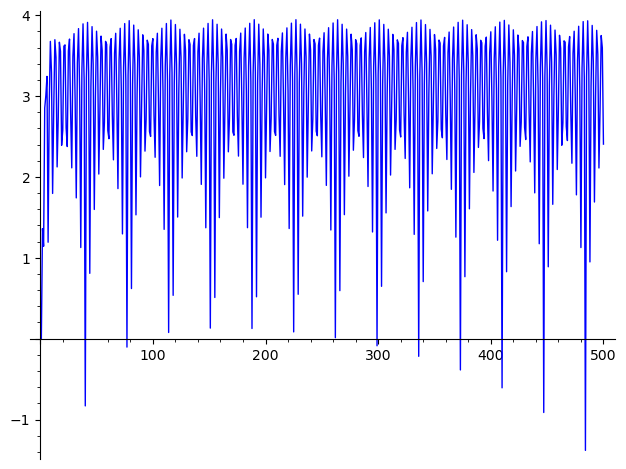

In [5]:
import pickle

with open('/Users/barrybrent/data2/run16jun26no7.txt', 'rb') as rfile:
    log_mins_list = pickle.load(rfile)

p = list_plot(log_mins_list, plotjoined=True, axes_labels=['', ''])
print("LOG MINIMUM MODULI")
p.show()  